In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [159]:
df = pd.read_csv('aqi_data.csv', skipinitialspace=True)
df

,date,pm25,pm10,no2,so2,co
0,2024/8/1,43.0,26.0,73.0,1.0,6.0
1,2024/8/2,45.0,21.0,66.0,1.0,5.0
2,2024/8/3,42.0,22.0,73.0,1.0,4.0
3,2024/8/4,40.0,18.0,96.0,2.0,5.0
4,2024/8/5,37.0,21.0,110.0,1.0,5.0
...,...,...,...,...,...,...
1626,2021/6/28,NaN,13.0,20.0,1.0,4.0
1627,2021/6/29,NaN,28.0,26.0,1.0,5.0
1628,2021/6/30,NaN,31.0,26.0,2.0,4.0
1629,2023/9/26,NaN,NaN,13.0,1.0,8.0


In [160]:
df['date'] = pd.to_datetime(df['date'])

In [161]:
all_dates = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')
missing_dates = all_dates.difference(df['date'])

print(f"Number of missing dates in sequence: {len(missing_dates)}")
print("First few missing dates:", missing_dates)

Number of missing dates in sequence: 15
First few missing dates: DatetimeIndex(['2020-03-01', '2020-03-23', '2020-03-24', '2020-03-25',
               '2020-03-26', '2020-06-03', '2020-06-04', '2020-06-05',
               '2020-06-06', '2020-06-07', '2020-06-13', '2020-06-14',
               '2020-10-18', '2022-01-07', '2022-01-08'],
              dtype='datetime64[ns]', freq=None)


In [162]:
df_complete = df.set_index('date').reindex(all_dates).rename_axis('date').reset_index()
df_complete

,date,pm25,pm10,no2,so2,co
0,2020-02-10,17.0,NaN,NaN,NaN,NaN
1,2020-02-11,54.0,NaN,NaN,NaN,NaN
2,2020-02-12,167.0,NaN,NaN,NaN,NaN
3,2020-02-13,88.0,NaN,NaN,NaN,NaN
4,2020-02-14,89.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
1641,2024-08-08,44.0,NaN,NaN,NaN,NaN
1642,2024-08-09,43.0,40.0,136.0,2.0,4.0
1643,2024-08-10,50.0,18.0,70.0,1.0,3.0
1644,2024-08-11,41.0,21.0,99.0,1.0,5.0


In [163]:
df_complete.isnull().sum()

date      0
pm25    207
pm10    366
no2     716
so2     301
co      292
dtype: int64

In [164]:
numeric_cols = ['pm25', 'pm10', 'no2', 'so2', 'co']
df_filled = df_complete.copy()
df_filled[numeric_cols] = df_filled[numeric_cols].interpolate(method='linear')
df_filled = df_filled.bfill().ffill()
df_filled.isnull().sum()

date    0
pm25    0
pm10    0
no2     0
so2     0
co      0
dtype: int64

In [165]:
df_filled

,date,pm25,pm10,no2,so2,co
0,2020-02-10,17.0,41.000000,1.000000,30.000000,2.000000
1,2020-02-11,54.0,41.000000,1.000000,30.000000,2.000000
2,2020-02-12,167.0,41.000000,1.000000,30.000000,2.000000
3,2020-02-13,88.0,41.000000,1.000000,30.000000,2.000000
4,2020-02-14,89.0,41.000000,1.000000,30.000000,2.000000
...,...,...,...,...,...,...
1641,2024-08-08,44.0,32.666667,121.333333,1.666667,3.666667
1642,2024-08-09,43.0,40.000000,136.000000,2.000000,4.000000
1643,2024-08-10,50.0,18.000000,70.000000,1.000000,3.000000
1644,2024-08-11,41.0,21.000000,99.000000,1.000000,5.000000


# coverting gases to aqi 

In [166]:
def calculate_aqi_p(cp, pollutant):
    # EPA Breakpoints Table
    breakpoints = {
        'pm25': [
            (0.0, 12.0, 0, 50), (12.1, 35.4, 51, 100), (35.5, 55.4, 101, 150),
            (55.5, 150.4, 151, 200), (150.5, 250.4, 201, 300), (250.5, 500.4, 301, 500)
        ],
        'pm10': [
            (0, 54, 0, 50), (55, 154, 51, 100), (155, 254, 101, 150),
            (255, 354, 151, 200), (355, 424, 201, 300), (425, 604, 301, 500)
        ],
        'no2': [
            (0, 53, 0, 50), (54, 100, 51, 100), (101, 360, 101, 150),
            (361, 649, 151, 200), (650, 1249, 201, 300), (1250, 2049, 301, 500)
        ],
        'so2': [
            (0, 35, 0, 50), (36, 75, 51, 100), (76, 185, 101, 150),
            (186, 304, 151, 200), (305, 604, 201, 300), (605, 1004, 301, 500)
        ],
        'co': [
            (0.0, 4.4, 0, 50), (4.5, 9.4, 51, 100), (9.5, 12.4, 101, 150),
            (12.5, 15.4, 151, 200), (15.5, 30.4, 201, 300), (30.5, 50.4, 301, 500)
        ]
    }
    
    if pollutant not in breakpoints: return np.nan
    if pd.isna(cp) or cp < 0: return np.nan

    # Find the correct breakpoint range
    for (bplo, bphi, ilo, ihi) in breakpoints[pollutant]:
        if bplo <= cp <= bphi:
            # The Formula: Ip = ((Ihi - Ilo) / (BPhi - BPlo)) * (Cp - BPlo) + Ilo
            aqi = ((ihi - ilo) / (bphi - bplo)) * (cp - bplo) + ilo
            return round(aqi)
    
    return 500 # Cap at 500 if above range

In [167]:
# Assuming df is your cleaned dataframe from previous steps
# We create new columns for the Index of each pollutant
df_filled['aqi_pm25'] = df_filled['pm25'].apply(lambda x: calculate_aqi_p(x, 'pm25'))
df_filled['aqi_pm10'] = df_filled['pm10'].apply(lambda x: calculate_aqi_p(x, 'pm10'))
df_filled['aqi_no2'] = df_filled['no2'].apply(lambda x: calculate_aqi_p(x, 'no2'))
df_filled['aqi_so2'] = df_filled['so2'].apply(lambda x: calculate_aqi_p(x, 'so2'))
df_filled['aqi_co'] = df_filled['co'].apply(lambda x: calculate_aqi_p(x, 'co'))

# Apply Eq (2): AQI = Max(Indices)
df_filled['final_aqi'] = df_filled[['aqi_pm25', 'aqi_pm10', 'aqi_no2', 'aqi_so2', 'aqi_co']].max(axis=1)

# Categorize the result
def get_status(aqi):
    if aqi <= 50: return "Good"
    if aqi <= 100: return "Moderate"
    if aqi <= 150: return "Unhealthy for Sensitive Groups"
    if aqi <= 200: return "Unhealthy"
    if aqi <= 300: return "Very Unhealthy"
    return "Hazardous"

df_filled['aqi_status'] = df_filled['final_aqi'].apply(get_status)

print(df_filled[['date', 'final_aqi', 'aqi_status']].head())

        date  final_aqi                      aqi_status
0 2020-02-10         61                        Moderate
1 2020-02-11        147  Unhealthy for Sensitive Groups
2 2020-02-12        217                  Very Unhealthy
3 2020-02-13        168                       Unhealthy
4 2020-02-14        168                       Unhealthy


In [168]:
df_filled = df_filled.drop(columns=['aqi_pm25','aqi_pm10', 'aqi_no2', 'aqi_so2', 'aqi_co'])
df_filled

,date,pm25,pm10,no2,so2,co,final_aqi,aqi_status
0,2020-02-10,17.0,41.000000,1.000000,30.000000,2.000000,61,Moderate
1,2020-02-11,54.0,41.000000,1.000000,30.000000,2.000000,147,Unhealthy for Sensitive Groups
2,2020-02-12,167.0,41.000000,1.000000,30.000000,2.000000,217,Very Unhealthy
3,2020-02-13,88.0,41.000000,1.000000,30.000000,2.000000,168,Unhealthy
4,2020-02-14,89.0,41.000000,1.000000,30.000000,2.000000,168,Unhealthy
...,...,...,...,...,...,...,...,...
1641,2024-08-08,44.0,32.666667,121.333333,1.666667,3.666667,122,Unhealthy for Sensitive Groups
1642,2024-08-09,43.0,40.000000,136.000000,2.000000,4.000000,119,Unhealthy for Sensitive Groups
1643,2024-08-10,50.0,18.000000,70.000000,1.000000,3.000000,137,Unhealthy for Sensitive Groups
1644,2024-08-11,41.0,21.000000,99.000000,1.000000,5.000000,115,Unhealthy for Sensitive Groups


In [169]:
numeric_cols.append('final_aqi')

# Visualization of data 

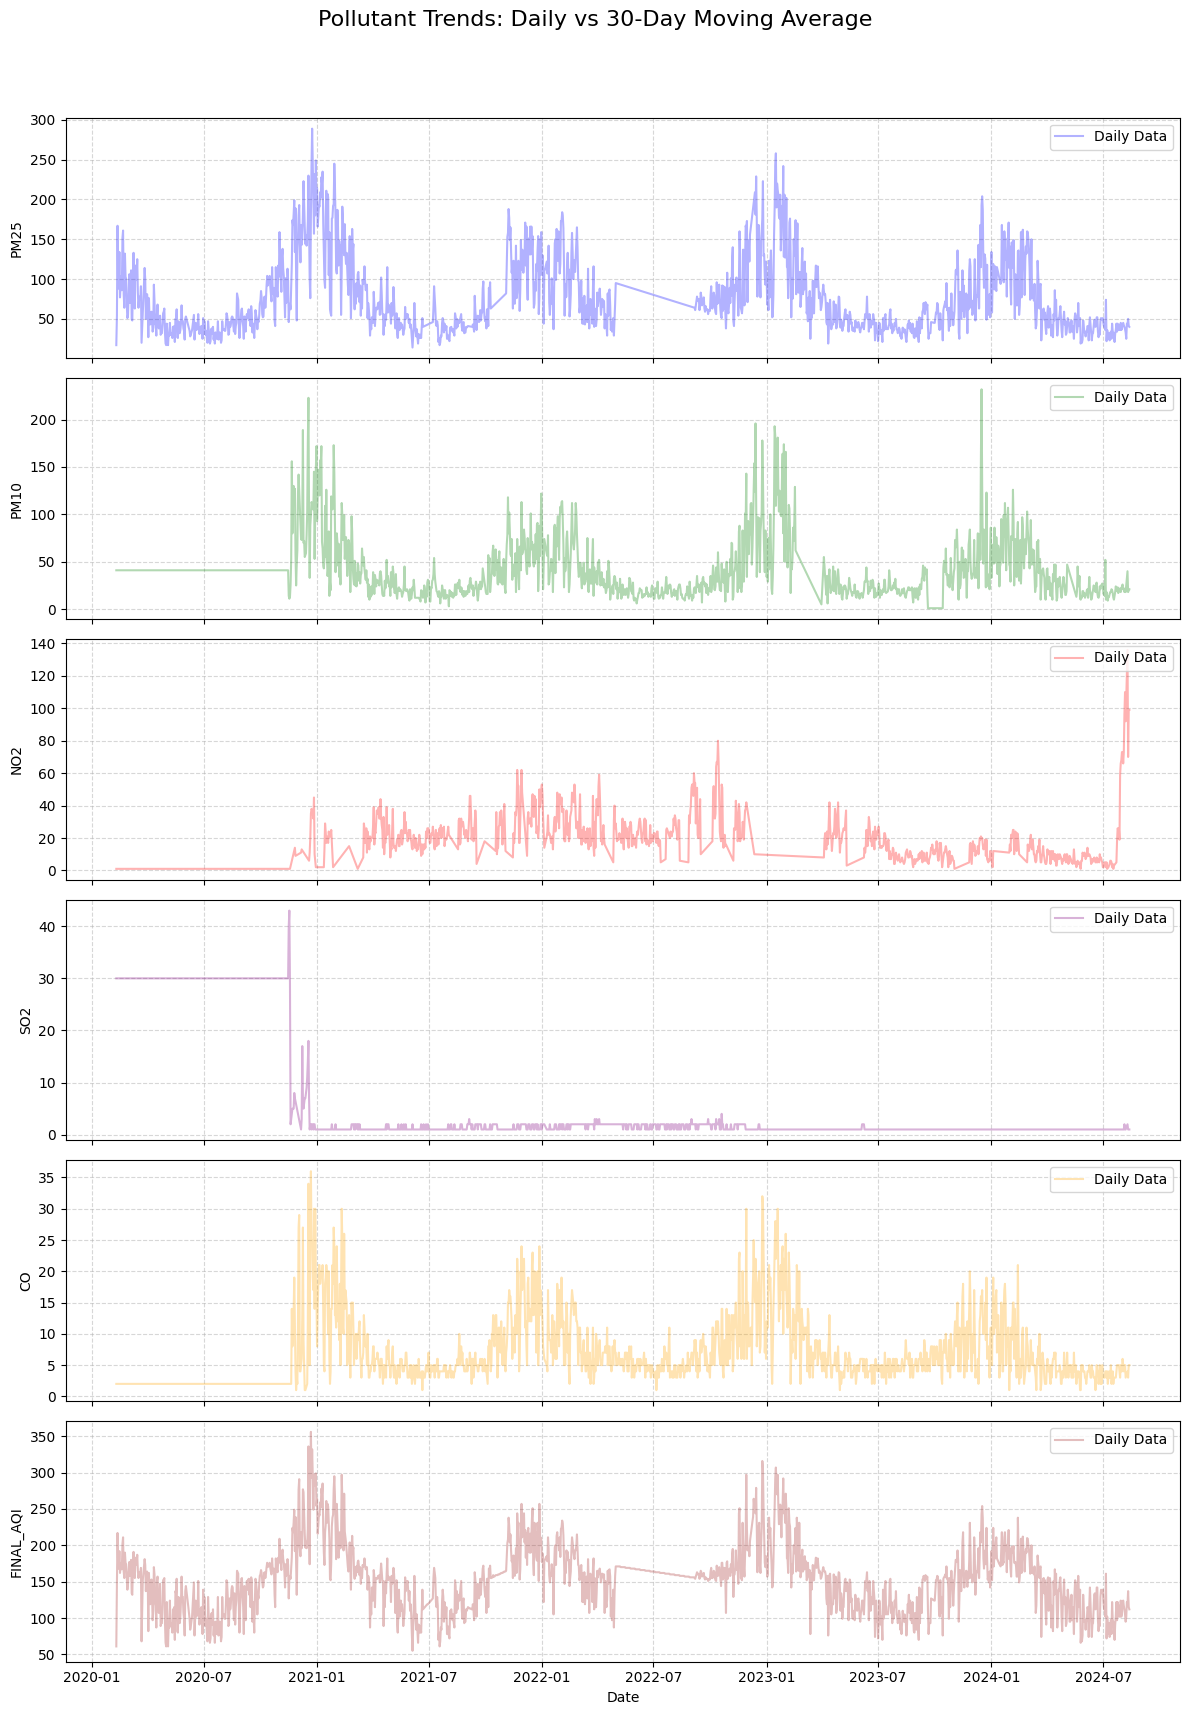

In [170]:
fig, axes = plt.subplots(6, 1, figsize=(12, 18), sharex=True)
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

for i, col in enumerate(numeric_cols):
    # Plot the raw daily data (lighter color)
    axes[i].plot(df_filled['date'], df_filled[col], color=colors[i], alpha=0.3, label='Daily Data')
    
    # Plot 30-day moving average (darker color)
    #ma_30 = df_filled[col].rolling(window=30).mean()
    #axes[i].plot(df_filled['date'], ma_30, color=colors[i], alpha=0.9, linewidth=2, label='30-Day MA')
    
    axes[i].set_ylabel(col.upper())
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Date')
plt.suptitle('Pollutant Trends: Daily vs 30-Day Moving Average', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/var/folders/hd/hqx41svd20lcfdp6nt85c0j80000gn/T/ipykernel_9074/3843488875.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Pollutant', y='Concentration', palette='Set2')


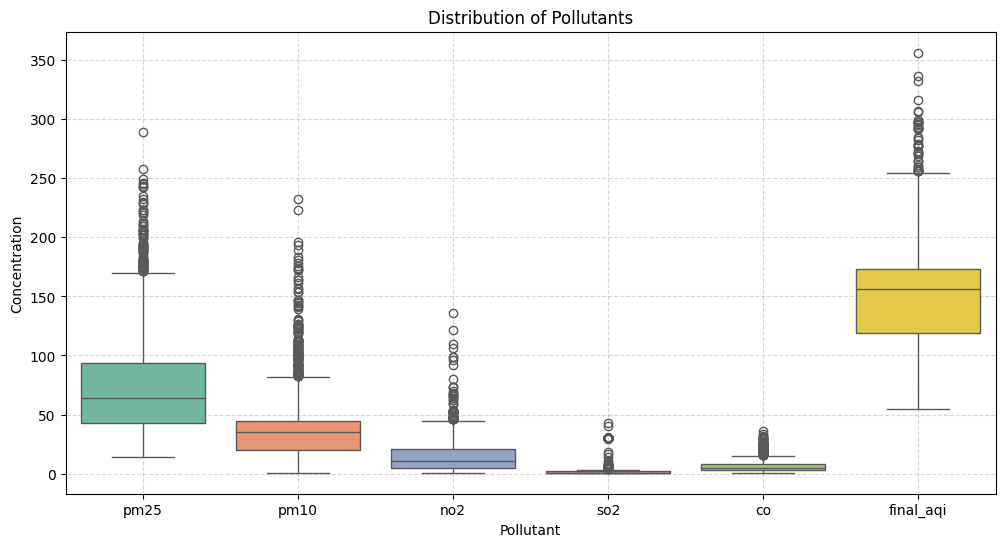

In [171]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(12, 6))
df_plot = df_filled[numeric_cols].melt(var_name='Pollutant', value_name='Concentration')
sns.boxplot(data=df_plot, x='Pollutant', y='Concentration', palette='Set2')
plt.title('Distribution of Pollutants')
plt.ylabel('Concentration')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

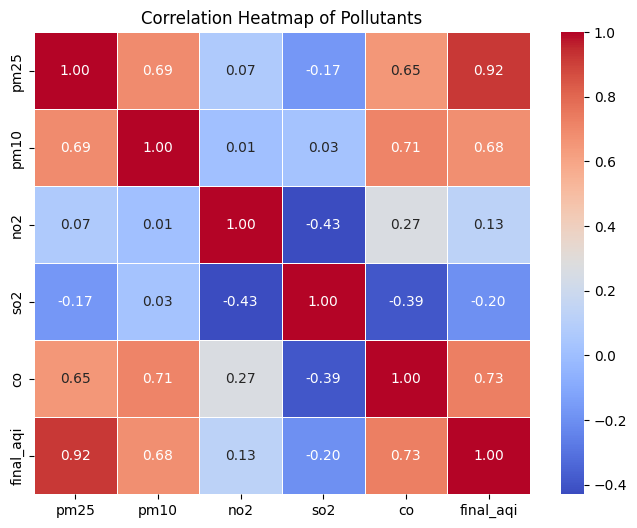

In [172]:

plt.figure(figsize=(8, 6))
correlation = df_filled[numeric_cols].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Pollutants')
plt.show()

## the higest correlation is between final_aqi and pm25 but i am not going to use final_aqi when i will train model bc it will be my target value (aqi_status)

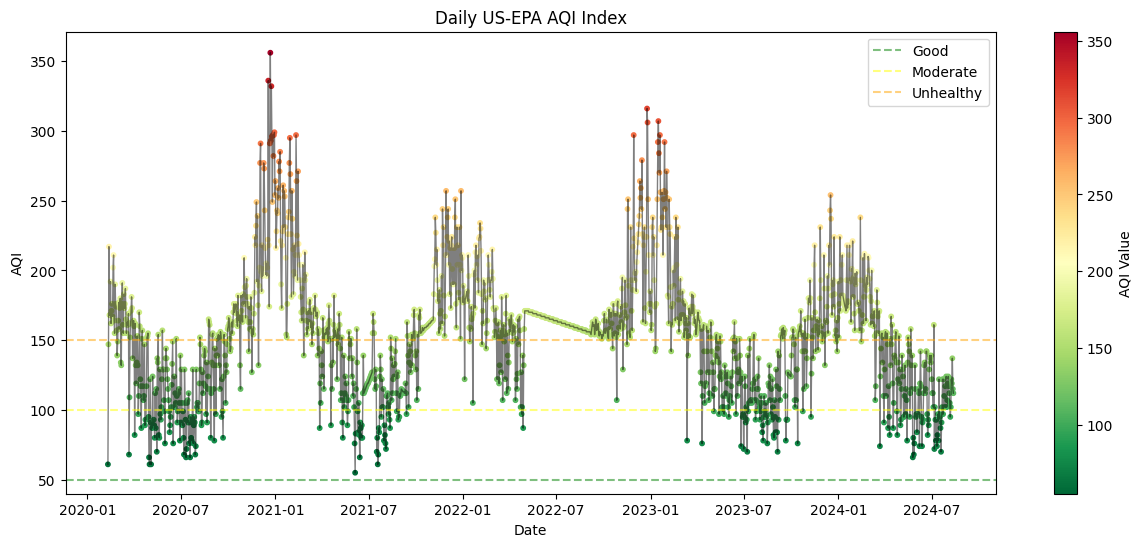

In [173]:
plt.figure(figsize=(15, 6))
plt.plot(df_filled['date'], df_filled['final_aqi'], color='black', linewidth=1, alpha=0.5)
plt.scatter(df_filled['date'], df_filled['final_aqi'], c=df_filled['final_aqi'], cmap='RdYlGn_r', s=10)

plt.axhline(50, color='green', linestyle='--', alpha=0.5, label='Good')
plt.axhline(100, color='yellow', linestyle='--', alpha=0.5, label='Moderate')
plt.axhline(150, color='orange', linestyle='--', alpha=0.5, label='Unhealthy')

plt.title('Daily US-EPA AQI Index')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend(loc='upper right')
plt.colorbar(label='AQI Value')
plt.show()

## data for tranig 

In [174]:
df_filled['month'] = df_filled['date'].dt.month
df_filled['dayofweek'] = df_filled['date'].dt.dayofweek
df_filled['is_weekend'] = (df_filled['date'].dt.dayofweek >= 5).astype(int)

In [175]:
df_filled

,date,pm25,pm10,no2,so2,co,final_aqi,aqi_status,month,dayofweek,is_weekend
0,2020-02-10,17.0,41.000000,1.000000,30.000000,2.000000,61,Moderate,2,0,0
1,2020-02-11,54.0,41.000000,1.000000,30.000000,2.000000,147,Unhealthy for Sensitive Groups,2,1,0
2,2020-02-12,167.0,41.000000,1.000000,30.000000,2.000000,217,Very Unhealthy,2,2,0
3,2020-02-13,88.0,41.000000,1.000000,30.000000,2.000000,168,Unhealthy,2,3,0
4,2020-02-14,89.0,41.000000,1.000000,30.000000,2.000000,168,Unhealthy,2,4,0
...,...,...,...,...,...,...,...,...,...,...,...
1641,2024-08-08,44.0,32.666667,121.333333,1.666667,3.666667,122,Unhealthy for Sensitive Groups,8,3,0
1642,2024-08-09,43.0,40.000000,136.000000,2.000000,4.000000,119,Unhealthy for Sensitive Groups,8,4,0
1643,2024-08-10,50.0,18.000000,70.000000,1.000000,3.000000,137,Unhealthy for Sensitive Groups,8,5,1
1644,2024-08-11,41.0,21.000000,99.000000,1.000000,5.000000,115,Unhealthy for Sensitive Groups,8,6,1


In [176]:
col_train = ['pm25', 'pm10', 'no2', 'so2', 'co', 'month', 'dayofweek', 'is_weekend']
X = df_filled[col_train]
y = df_filled['aqi_status']

In [177]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [178]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [179]:
# Check for any missing values
print("Missing values in X:")
print(X.isnull().sum())
print("\nMissing values in y:")
print(y.isnull().sum())

# Check class distribution
print("\nClass distribution in y:")
print(y.value_counts())

# Check data shapes
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Check feature statistics
print("\nFeature statistics:")
print(X.describe())

Missing values in X:
pm25          0
pm10          0
no2           0
so2           0
co            0
month         0
dayofweek     0
is_weekend    0
dtype: int64

Missing values in y:
0

Class distribution in y:
aqi_status
Unhealthy                         776
Unhealthy for Sensitive Groups    461
Moderate                          204
Very Unhealthy                    199
Hazardous                           6
Name: count, dtype: int64

X shape: (1646, 8)
y shape: (1646,)
X_train shape: (1316, 8)
X_test shape: (330, 8)

Feature statistics:
              pm25         pm10          no2          so2           co  \
count  1646.000000  1646.000000  1646.000000  1646.000000  1646.000000   
mean     76.223572    40.272175    14.640340     6.305286     6.728736   
std      44.530912    29.995769    14.188726    10.886165     5.365253   
min      14.000000     1.000000     1.000000     1.000000     1.000000   
25%      43.000000    20.000000     5.000000     1.000000     3.000000   
50%      64

# Random Forest

In [180]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [181]:
from sklearn.model_selection import train_test_split

# Use 'stratify=y' to keep the class proportions the same in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [182]:
'''from imblearn.over_sampling import SMOTE

# This creates synthetic samples for the minority classes
smote = SMOTE(random_state=42, k_neighbors=2) # k_neighbors=2 because you only have 6 samples
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Train your model on X_resampled instead
model.fit(X_resampled, y_resampled)'''

'from imblearn.over_sampling import SMOTE\n\n# This creates synthetic samples for the minority classes\nsmote = SMOTE(random_state=42, k_neighbors=2) # k_neighbors=2 because you only have 6 samples\nX_resampled, y_resampled = smote.fit_resample(X_train, y_train)\n\n# Train your model on X_resampled instead\nmodel.fit(X_resampled, y_resampled)'

In [183]:
'''from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
# Look at the 'macro avg' in this report
print(classification_report(y_test, y_pred))'''

"from sklearn.metrics import classification_report, confusion_matrix\n\ny_pred = model.predict(X_test)\n# Look at the 'macro avg' in this report\nprint(classification_report(y_test, y_pred))"

In [184]:
'''from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Where are the mistakes happening?')
plt.show()'''

"from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay\nimport matplotlib.pyplot as plt\n\n# Generate the confusion matrix\ncm = confusion_matrix(y_test, y_pred, labels=model.classes_)\ndisp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)\n\nfig, ax = plt.subplots(figsize=(10, 8))\ndisp.plot(ax=ax, cmap='Blues', xticks_rotation=45)\nplt.title('Where are the mistakes happening?')\nplt.show()"

In [185]:
# Manually define higher importance for the rare class
custom_weights = {
    'Unhealthy': 1,
    'Unhealthy for Sensitive Groups': 2,
    'Moderate': 5,
    'Very Unhealthy': 10,
    'Hazardous': 50  # Give Hazardous a massive boost
}

model = RandomForestClassifier(class_weight=custom_weights, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [186]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5) # Ensure each fold gets at least one 'Hazardous'
# Use 'f1_macro' as the score because it cares about the small classes
scores = cross_val_score(model, X, y, cv=skf, scoring='f1_macro')

print(f"Average F1-Macro Score: {scores.mean():.2f}")

Average F1-Macro Score: 0.79


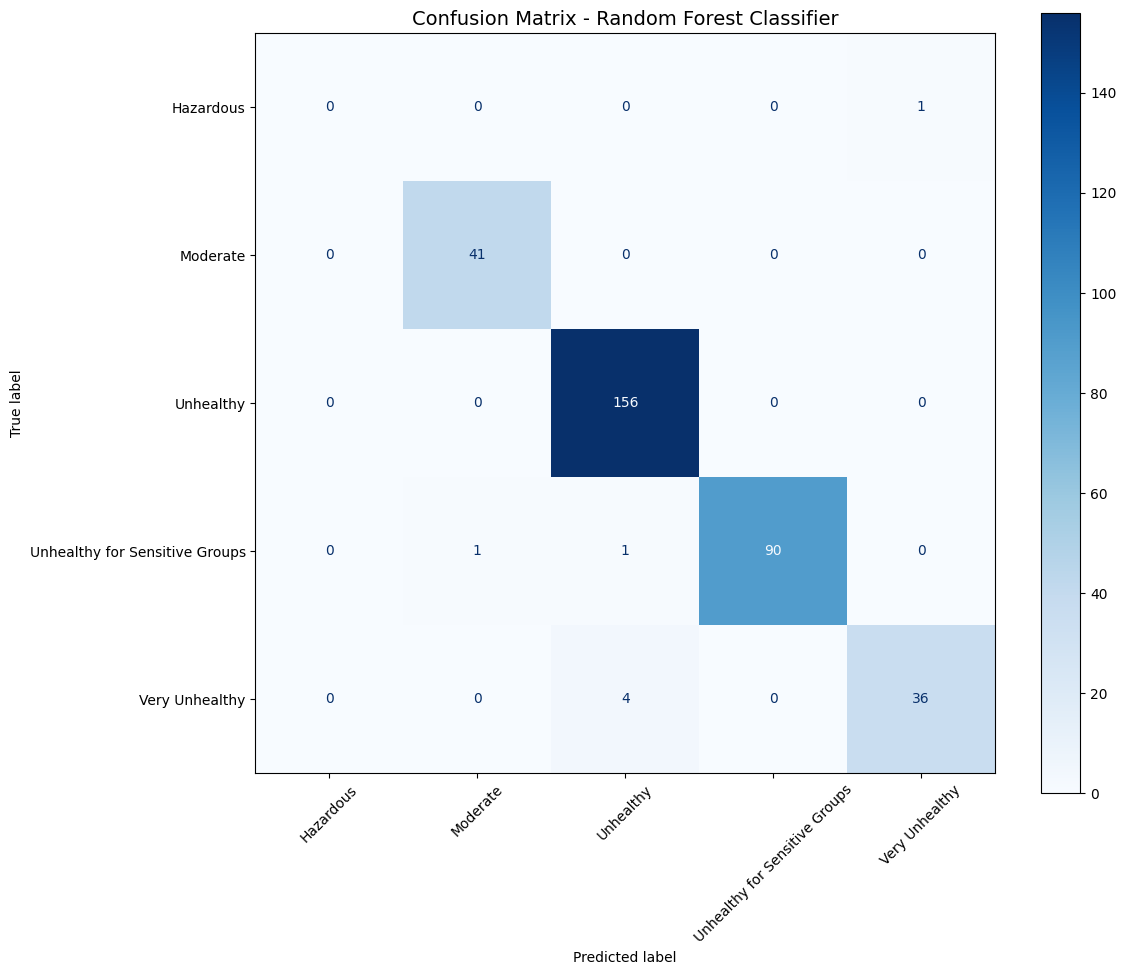

In [187]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
y_pred = model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix - Random Forest Classifier', fontsize=14)
plt.tight_layout()
plt.show()

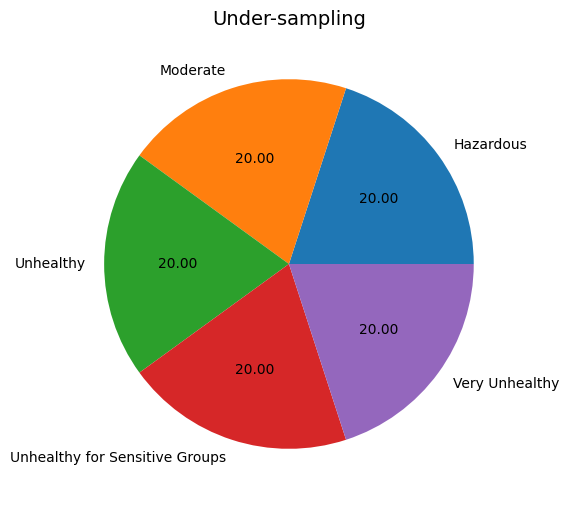

In [188]:
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)

fig, ax = plt.subplots(figsize=(8, 6))
y_res.value_counts().plot.pie(autopct='%.2f', ax=ax)
ax.set_title("Under-sampling", fontsize=14)
ax.set_ylabel('')
plt.show()

In [189]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

In [197]:
# Check for any missing values
print("Missing values in X:")
print(X_res.isnull().sum())
print("\nMissing values in y:")
print(y_res.isnull().sum())

# Check class distribution
print("\nClass distribution in y:")
print(y_res.value_counts())

# Check data shapes
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Check feature statistics
print("\nFeature statistics:")
print(X.describe())

Missing values in X:
pm25          0
pm10          0
no2           0
so2           0
co            0
month         0
dayofweek     0
is_weekend    0
dtype: int64

Missing values in y:
0

Class distribution in y:
aqi_status
Hazardous                         6
Moderate                          6
Unhealthy                         6
Unhealthy for Sensitive Groups    6
Very Unhealthy                    6
Name: count, dtype: int64

X shape: (1646, 8)
y shape: (1646,)
X_train shape: (1316, 8)
X_test shape: (330, 8)

Feature statistics:
              pm25         pm10          no2          so2           co  \
count  1646.000000  1646.000000  1646.000000  1646.000000  1646.000000   
mean     76.223572    40.272175    14.640340     6.305286     6.728736   
std      44.530912    29.995769    14.188726    10.886165     5.365253   
min      14.000000     1.000000     1.000000     1.000000     1.000000   
25%      43.000000    20.000000     5.000000     1.000000     3.000000   
50%      64.000000   

In [190]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [191]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

In [192]:
model_base = RandomForestClassifier(random_state=42)
model_base.fit(X_train, y_train)
y_pred_base = model_base.predict(X_test)
print("--- Baseline Report ---")
print(classification_report(y_test, y_pred_base))

--- Baseline Report ---
                                precision    recall  f1-score   support

                     Hazardous       0.00      0.00      0.00         1
                      Moderate       0.98      1.00      0.99        41
                     Unhealthy       1.00      1.00      1.00       156
Unhealthy for Sensitive Groups       1.00      0.99      0.99        92
                Very Unhealthy       0.98      1.00      0.99        40

                      accuracy                           0.99       330
                     macro avg       0.79      0.80      0.79       330
                  weighted avg       0.99      0.99      0.99       330



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [193]:
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)

model_ros = RandomForestClassifier(random_state=42)
model_ros.fit(X_ros, y_ros)
print("--- Random Over-Sampling Report ---")
print(classification_report(y_test, model_ros.predict(X_test)))

--- Random Over-Sampling Report ---
                                precision    recall  f1-score   support

                     Hazardous       0.00      0.00      0.00         1
                      Moderate       0.98      1.00      0.99        41
                     Unhealthy       0.99      0.98      0.99       156
Unhealthy for Sensitive Groups       1.00      0.99      0.99        92
                Very Unhealthy       0.91      0.97      0.94        40

                      accuracy                           0.98       330
                     macro avg       0.78      0.79      0.78       330
                  weighted avg       0.98      0.98      0.98       330



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [194]:
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)

model_rus = RandomForestClassifier(random_state=42)
model_rus.fit(X_rus, y_rus)
print("--- Random Under-Sampling Report ---")
print(classification_report(y_test, model_rus.predict(X_test)))

--- Random Under-Sampling Report ---
                                precision    recall  f1-score   support

                     Hazardous       0.12      1.00      0.22         1
                      Moderate       0.68      0.68      0.68        41
                     Unhealthy       0.95      0.53      0.68       156
Unhealthy for Sensitive Groups       0.70      0.89      0.78        92
                Very Unhealthy       0.40      0.78      0.53        40

                      accuracy                           0.68       330
                     macro avg       0.57      0.78      0.58       330
                  weighted avg       0.78      0.68      0.69       330



In [195]:
# k_neighbors=2 is required because you only have 6 samples
smote = SMOTE(random_state=42, k_neighbors=2)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

model_smote = RandomForestClassifier(random_state=42)
model_smote.fit(X_smote, y_smote)
print("--- SMOTE Report ---")
print(classification_report(y_test, model_smote.predict(X_test)))

--- SMOTE Report ---
                                precision    recall  f1-score   support

                     Hazardous       0.00      0.00      0.00         1
                      Moderate       0.98      1.00      0.99        41
                     Unhealthy       0.99      0.99      0.99       156
Unhealthy for Sensitive Groups       1.00      0.98      0.99        92
                Very Unhealthy       0.93      0.97      0.95        40

                      accuracy                           0.98       330
                     macro avg       0.78      0.79      0.78       330
                  weighted avg       0.98      0.98      0.98       330



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha